<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Percobaan 3

Pada percobaan ini digunakan **5 tahapan preprocessing**, yaitu:
1. Grayscale
2. Resize
3. Median Filter
4. Sobel Edge Detection
5. Roberts Edge Detection

In [2]:
!pip install opendatasets

In [1]:
mkdir -p ~/.kaggle && echo KGAT_fcfb3f7b7bad3fc8d54795b90c6322d5 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [2]:
import os
import json
import opendatasets as od

# 1. Put your Kaggle credentials here
kaggle_creds = {
    "username": "tunabakar",
    "key": "KGAT_fcfb3f7b7bad3fc8d54795b90c6322d5"
}

# 2. Write the credentials to a kaggle.json file in the current working directory
with open('kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# 3. Now download will run automatically without asking for input
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:08<00:00, 19.0MB/s] 


In [3]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [4]:
data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in files:
            if class_counters[folder_aktif] >= 300:
                break
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:
                    # Sesuai template: cuma Grayscale (Resize dilakukan di tahap preprocessing)
                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")
print("Label unik:", np.unique(labels))

Sukses membaca data mentah! Total data awal: 600 gambar.
Label unik: ['glioma' 'notumor']


In [5]:
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} gambar")
print(f"Total data: {len(data)} gambar")

Kelas glioma: 300 gambar
Kelas notumor: 300 gambar
Total data: 600 gambar


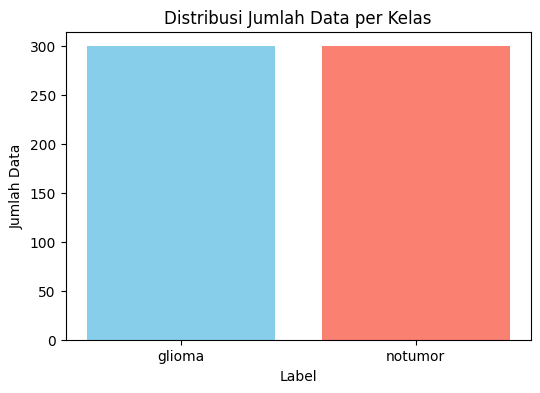

In [6]:
# Visualisasi distribusi data
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['skyblue','salmon'])
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.show()

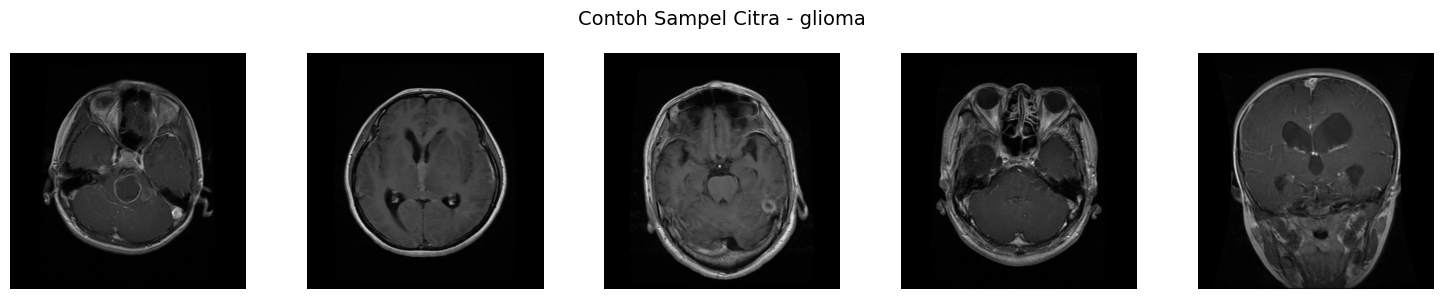

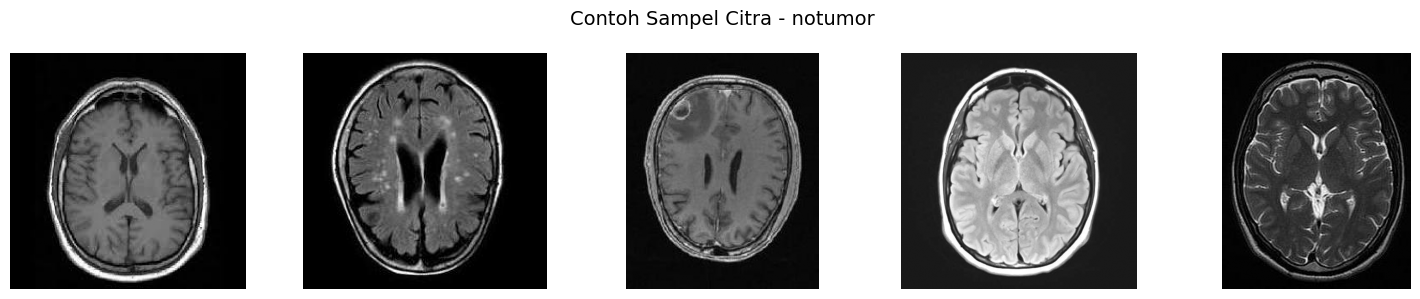

In [7]:
# Contoh sampel data tiap kelas
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f'Contoh Sampel Citra - {label}', fontsize=14)
    for k in range(5):
        axs[k].imshow(data[idxs[k]], cmap='gray')
        axs[k].axis('off')
    plt.tight_layout()
    plt.show()

In [8]:
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):
    img_asli = data[i]
    label_asli = labels[i]
    nama_asli = file_name[i]

    data_augmented.append(img_asli)
    labels_augmented.append(label_asli)
    file_name_augmented.append(f"asli_{nama_asli}")

    img_flip = img_asli[:, ::-1]
    data_augmented.append(img_flip)
    labels_augmented.append(label_asli)
    file_name_augmented.append(f"flip_{nama_asli}")

    img_rot = img_asli.T[:, ::-1]
    data_augmented.append(img_rot)
    labels_augmented.append(label_asli)
    file_name_augmented.append(f"rot90_{nama_asli}")

data_augmented = np.array(data_augmented, dtype=object)
labels_augmented = np.array(labels_augmented)

print("--- Augmentasi Selesai! ---")
print(f"Total data setelah augmentasi: {len(data_augmented)} gambar.")

--- Augmentasi Selesai! ---
Total data setelah augmentasi: 1800 gambar.


In [9]:
def grayscale(image):
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def resize(image, target_size):
    return cv.resize(image, target_size)

def median(image, rowkernel, columnkernel):
    row, column = int(rowkernel/2), int(columnkernel/2)
    image_pad = np.pad(image, [(row, row), (column, column)], mode="edge")
    result = np.zeros(image.shape)

    for i in range(row, image.shape[0] + row):
        for j in range(column, image.shape[1] + column):
            submatrix = image_pad[i-row:i+row+1, j-column:j+column+1]
            result[i-row, j-column] = np.median(submatrix)

    return result.astype(np.uint8)

In [10]:
def sobel(image):
    sobelx = cv.Sobel(image, cv.CV_64F, 1, 0, ksize=3)
    sobely = cv.Sobel(image, cv.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = (magnitude / magnitude.max()) * 255 if magnitude.max() != 0 else magnitude
    return magnitude.astype(np.uint8)

def roberts(image):
    kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float64)
    kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float64)

    img_f = image.astype(np.float64)
    gx = cv.filter2D(img_f, -1, kernel_x)
    gy = cv.filter2D(img_f, -1, kernel_y)

    magnitude = np.sqrt(gx**2 + gy**2)
    magnitude = (magnitude / magnitude.max()) * 255 if magnitude.max() != 0 else magnitude
    return magnitude.astype(np.uint8)

In [11]:
def percobaan3(image):
    img_gray = grayscale(image)
    img_resize = resize(img_gray, (256, 256))
    img_median = median(img_resize, 3, 3)
    img_sobel = sobel(img_median)
    img_roberts = roberts(img_sobel)
    return img_roberts

dataPreprocessed = []

print("Sedang mengeksekusi Preprocessing Percobaan 3 (Grayscale + Resize + Median + Sobel + Roberts)...")

for i in range(len(data_augmented)):
    img_hasil = percobaan3(data_augmented[i])
    dataPreprocessed.append(img_hasil)

dataPreprocessed = np.array(dataPreprocessed)

print("--- Selesai! ---")
print(f"Total citra hasil Percobaan 3: {len(dataPreprocessed)} gambar.")

Sedang mengeksekusi Preprocessing Percobaan 3 (Grayscale + Resize + Median + Sobel + Roberts)...
--- Selesai! ---
Total citra hasil Percobaan 3: 1800 gambar.


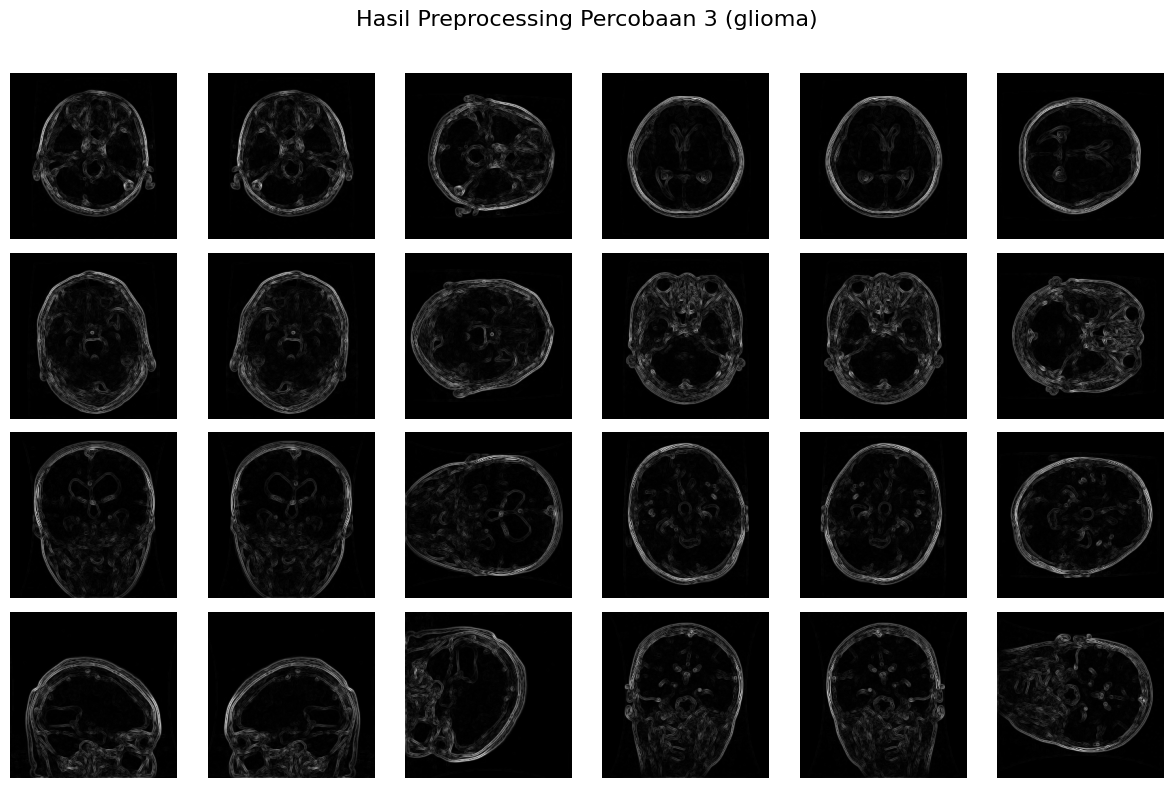

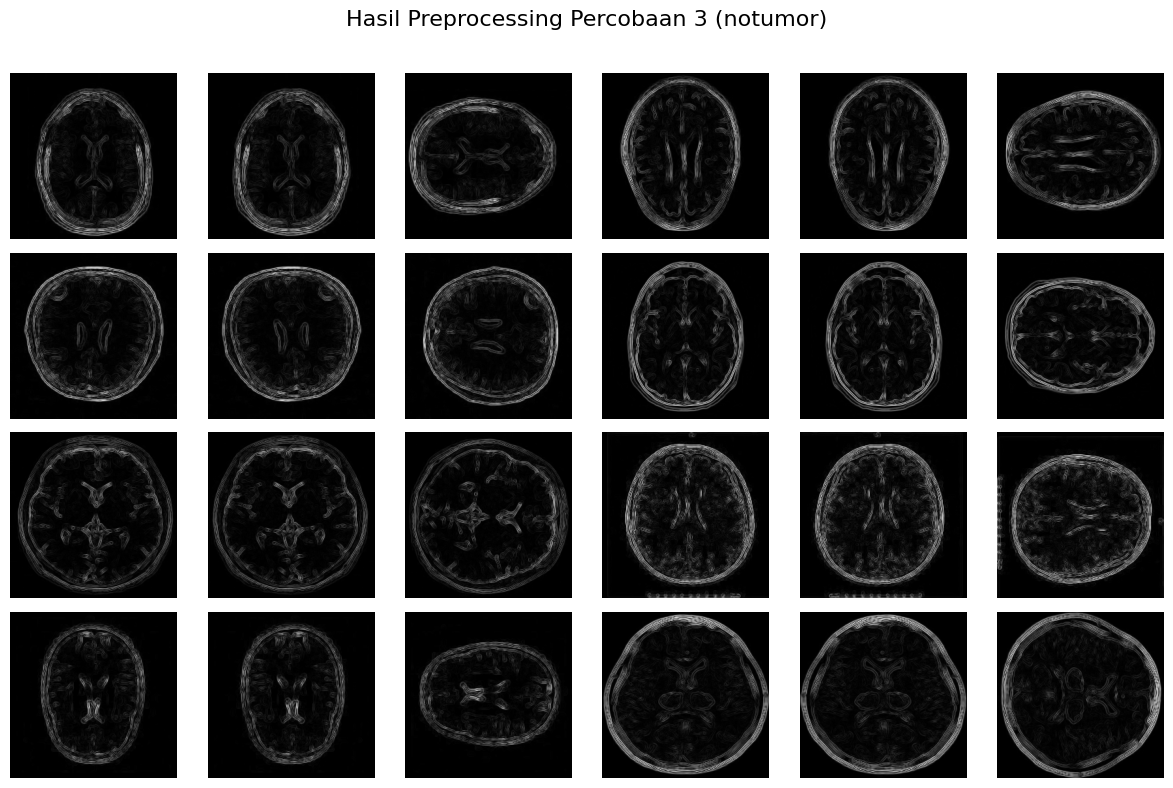

In [12]:
unique_labels = sorted(set(labels_augmented))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels_augmented) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Hasil Preprocessing Percobaan 3 ({label})', fontsize=16)

    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]

        img_idx = idxs[k]
        ax.imshow(dataPreprocessed[img_idx], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [13]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

    return glcm

In [14]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [15]:
for i in range(len(dataPreprocessed)):
    dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8)

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks GLCM untuk setiap sudut! ---")

--- Sukses membuat matriks GLCM untuk setiap sudut! ---


In [16]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print("--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---")

--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---


In [17]:
dataTable = {
    'Filename': file_name_augmented,
    'Label': labels_augmented,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
display(hasilEkstrak)

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,asli_no-0959.jpg,notumor,538.419485,644.899685,389.222794,647.653549,0.526094,0.498131,0.543988,0.497705,...,0.123769,0.103994,0.335227,0.322502,0.351809,0.322481,0.689151,0.628809,0.775300,0.627224
1,flip_no-0959.jpg,notumor,538.419485,647.653549,389.222794,644.899685,0.526094,0.497705,0.543988,0.498131,...,0.123769,0.104007,0.335227,0.322481,0.351809,0.322502,0.689151,0.627224,0.775300,0.628809
2,rot90_no-0959.jpg,notumor,388.765426,647.356540,538.532292,644.744191,0.544943,0.496279,0.524144,0.496968,...,0.111653,0.103756,0.352402,0.321708,0.334145,0.322112,0.775569,0.627403,0.689092,0.628906
3,asli_no-1728.jpg,notumor,611.810754,625.336947,383.726547,627.932872,0.516749,0.503047,0.530758,0.502333,...,0.167938,0.161155,0.406452,0.401621,0.409803,0.401441,0.667471,0.661120,0.791439,0.659713
4,flip_no-1728.jpg,notumor,611.810754,627.932872,383.726547,625.336947,0.516749,0.502333,0.530758,0.503047,...,0.167938,0.161299,0.406452,0.401441,0.409803,0.401621,0.667471,0.659713,0.791439,0.661120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,flip_gl-0703.jpg,glioma,464.787423,542.276463,352.279350,518.900438,0.382981,0.347178,0.391559,0.349562,...,0.026025,0.021899,0.159366,0.147478,0.161324,0.147984,0.664349,0.609033,0.745314,0.625887
1796,rot90_gl-0703.jpg,glioma,352.278431,542.409735,464.921094,519.033710,0.391465,0.345076,0.380981,0.347460,...,0.024999,0.021536,0.159969,0.146244,0.158110,0.146752,0.745942,0.609895,0.665072,0.626707
1797,asli_gl-1362.jpg,glioma,442.642525,549.648689,377.416146,542.255102,0.568552,0.545317,0.574901,0.546532,...,0.153288,0.144414,0.394026,0.380185,0.391520,0.380019,0.690107,0.616428,0.735776,0.621588
1798,flip_gl-1362.jpg,glioma,442.642525,542.255102,377.416146,549.648689,0.568552,0.546532,0.574901,0.545317,...,0.153288,0.144541,0.394026,0.380019,0.391520,0.380185,0.690107,0.621588,0.735776,0.616428


Jumlah fitur sebelum seleksi: 28
Jumlah fitur setelah seleksi: 11


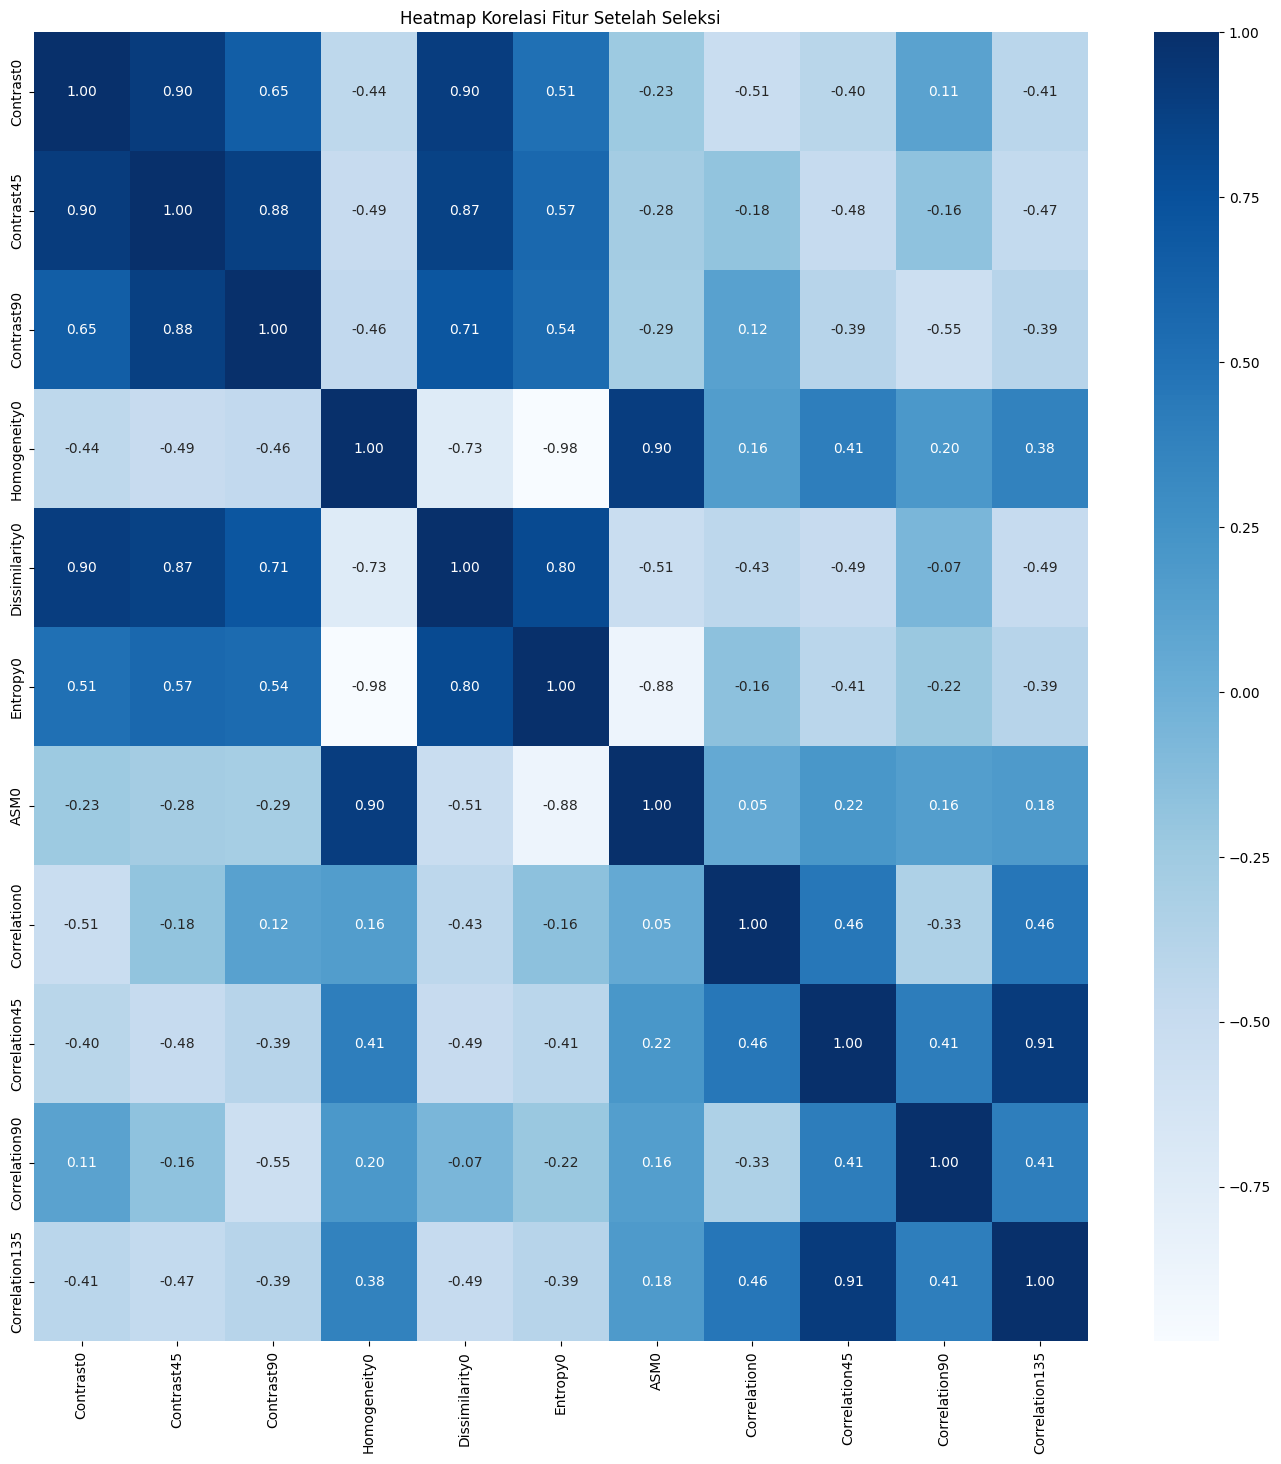

In [18]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.95
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {correlation.shape[0]}")
print(f"Jumlah fitur setelah seleksi: {x_new.shape[1]}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Setelah Seleksi')
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1440, 11)
(360, 11)
(1440,)
(360,)


In [20]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [21]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [22]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       722
     notumor       0.99      0.99      0.99       718

    accuracy                           0.99      1440
   macro avg       0.99      0.99      0.99      1440
weighted avg       0.99      0.99      0.99      1440

[[715   7]
 [  5 713]]
Accuracy: 0.9916666666666667

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.92      0.91      0.92       178
     notumor       0.91      0.92      0.92       182

    accuracy                           0.92       360
   macro avg       0.92      0.92      0.92       360
weighted avg       0.92      0.92      0.92       360

[[162  16]
 [ 14 168]]
Accuracy: 0.9166666666666666


In [23]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.87      0.92      0.90       722
     notumor       0.92      0.86      0.89       718

    accuracy                           0.89      1440
   macro avg       0.89      0.89      0.89      1440
weighted avg       0.89      0.89      0.89      1440

[[666  56]
 [100 618]]
Accuracy: 0.8916666666666667

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.86      0.90      0.88       178
     notumor       0.90      0.85      0.88       182

    accuracy                           0.88       360
   macro avg       0.88      0.88      0.88       360
weighted avg       0.88      0.88      0.88       360

[[161  17]
 [ 27 155]]
Accuracy: 0.8777777777777778


In [24]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.94      0.96      0.95       722
     notumor       0.96      0.93      0.95       718

    accuracy                           0.95      1440
   macro avg       0.95      0.95      0.95      1440
weighted avg       0.95      0.95      0.95      1440

[[694  28]
 [ 48 670]]
Accuracy: 0.9472222222222222

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.90      0.92      0.91       178
     notumor       0.92      0.90      0.91       182

    accuracy                           0.91       360
   macro avg       0.91      0.91      0.91       360
weighted avg       0.91      0.91      0.91       360

[[163  15]
 [ 19 163]]
Accuracy: 0.9055555555555556


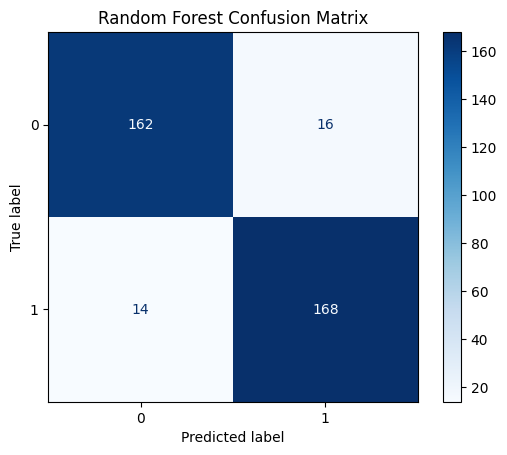

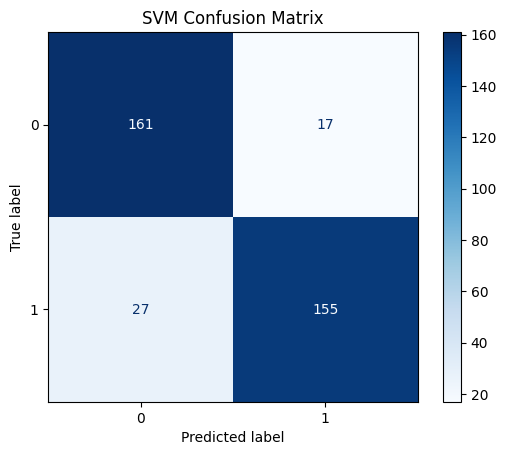

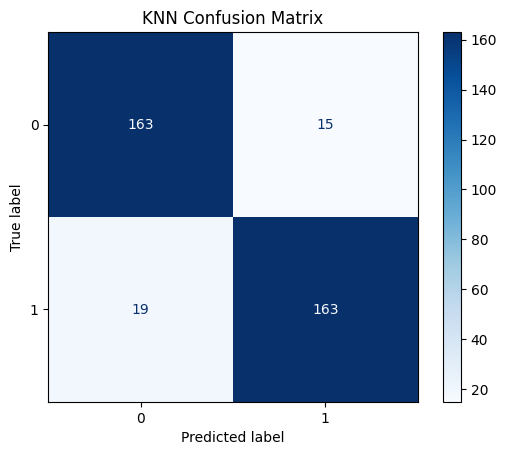

In [25]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")